# CS 4630: Building Supervised Learning Models with Regression and LDA Techniques
Author: Devin Khun

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

# combine into one dataframe
heart = pd.concat(
    [heart_disease.data.features, heart_disease.data.targets],
    axis=1
)

# view it
print(heart.head())
print(heart.shape)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## Linear Regression

In [3]:
with open("./boston.txt") as f:
    cn = f.readline().strip().lower().split("\t")

boston = pd.read_csv(
    "./boston.txt",
    sep="\t",
    skiprows=1,
    header=None,
    names=cn
)

# Baseline RMSE and standard deviation of the response variable
yhat = boston["cmedv"].mean()
rmse0 = np.sqrt(((boston["cmedv"] - yhat) ** 2).mean())
sdY = boston["cmedv"].std()

print(rmse0)
print(sdY)

9.173098098551435
9.18217588216678


In [4]:
# simple linear regression
slr = smf.ols("cmedv ~ rm", data=boston).fit()

# equivalent to summary(slr)
print(slr.summary())

# predictions
yhat = slr.predict(boston)

# RMSE
rmse_slr = np.sqrt(np.mean((boston["cmedv"] - yhat) ** 2))
print("rmse_slr:", rmse_slr)

                            OLS Regression Results                            
Dep. Variable:                  cmedv   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     474.3
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.31e-74
Time:                        15:29:33   Log-Likelihood:                -1671.6
No. Observations:                 506   AIC:                             3347.
Df Residuals:                     504   BIC:                             3356.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6592      2.642    -13.118      0.0

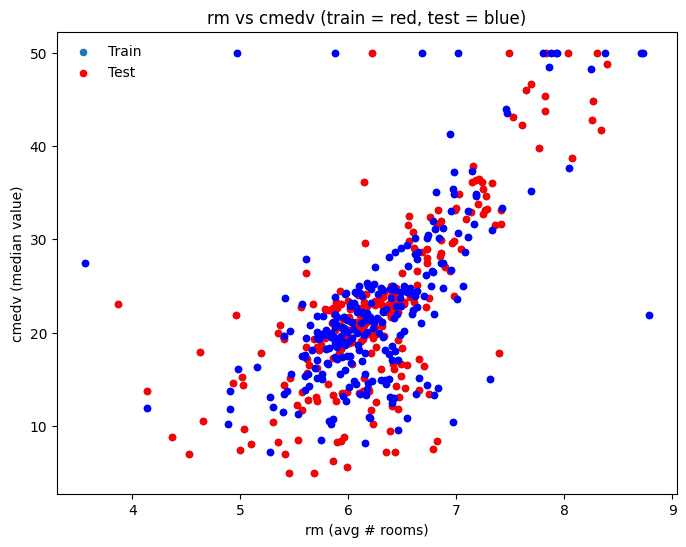

In [5]:
n = len(boston)
n_train = int(np.ceil(n / 2))
n_test = n - n_train

np.random.seed(4330)
obs_train = np.sort(np.random.choice(np.arange(n), size=n_train, replace=False))
obs_test = np.setdiff1d(np.arange(n), obs_train)

plt.figure(figsize=(8, 6))
plt.scatter(boston["rm"], boston["cmedv"], s=20)
plt.scatter(boston.loc[obs_train, "rm"], boston.loc[obs_train, "cmedv"], c="red", s=20)
plt.scatter(boston.loc[obs_test, "rm"], boston.loc[obs_test, "cmedv"], c="blue", s=20)

plt.xlabel("rm (avg # rooms)")
plt.ylabel("cmedv (median value)")
plt.title("rm vs cmedv (train = red, test = blue)")
plt.legend(["Train", "Test"], loc="upper left", frameon=False)
plt.show()

In [6]:
# make separate variables for the y values from the training and test sets
y_train = boston.loc[obs_train, "cmedv"]
y_test = boston.loc[obs_test, "cmedv"]

# training and test dataframes
boston_train = boston.loc[obs_train].copy()
boston_test = boston.loc[obs_test].copy()

# fit the model to the training data only
slr_train = smf.ols("cmedv ~ rm", data=boston_train).fit()
print(slr_train.summary())

# obtain predictions on the training data
yhat_train = slr_train.predict(boston_train)

# calculate and print the training data root mean squared error
rmse_slr_train = np.sqrt(np.mean((y_train - yhat_train) ** 2))
print("rmse_slr_train:", rmse_slr_train)

# obtain predictions on the test data set
yhat_test = slr_train.predict(boston_test)

# calculate and print the test data root mean squared error
rmse_slr_test = np.sqrt(np.mean((y_test - yhat_test) ** 2))
print("rmse_slr_test:", rmse_slr_test)

                            OLS Regression Results                            
Dep. Variable:                  cmedv   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     313.1
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.89e-46
Time:                        15:29:33   Log-Likelihood:                -822.30
No. Observations:                 253   AIC:                             1649.
Df Residuals:                     251   BIC:                             1656.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -38.3114      3.454    -11.090      0.0

In [7]:
# make separate variables for the y values from the training and test sets
y_train = boston.loc[obs_train, "cmedv"]
y_test = boston.loc[obs_test, "cmedv"]

# fit the model to the training data only
mlr_train = smf.ols(
    "cmedv ~ crim + zn + indus + chas + nox + rm + age + dis + lstat",
    data=boston_train
).fit()
print(mlr_train.summary())

# obtain predictions on the training data
yhat_train = mlr_train.predict(boston_train)

# calculate and print the training data root mean squared error
rmse_mlr_train = np.sqrt(np.mean((y_train - yhat_train) ** 2))
print("rmse_mlr_train:", rmse_mlr_train)

# obtain predictions on the test data set
yhat_test = mlr_train.predict(boston_test)

# calculate and print the test data root mean squared error
rmse_mlr_test = np.sqrt(np.mean((y_test - yhat_test) ** 2))
print("rmse_mlr_test:", rmse_mlr_test)

                            OLS Regression Results                            
Dep. Variable:                  cmedv   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     74.84
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.55e-65
Time:                        15:29:33   Log-Likelihood:                -756.81
No. Observations:                 253   AIC:                             1534.
Df Residuals:                     243   BIC:                             1569.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.9296      5.360      2.039      0.0

## Logistic Regression

In [8]:
# --------------------
# Part B
# --------------------

# equivalent to table(heart$ca)
print("ca frequency table:")
print(heart["ca"].value_counts(dropna=False))
print()

# equivalent to table(heart$thal)
print("thal frequency table:")
print(heart["thal"].value_counts(dropna=False))
print()

# subset(heart, ca != "?" & thal != "?")
heart = heart[(heart["ca"] != "?") & (heart["thal"] != "?")].copy()
heart.dropna(inplace=True)

# as.numeric
heart["ca"] = pd.to_numeric(heart["ca"])
heart["thal"] = pd.to_numeric(heart["thal"])

# equivalent to str(heart)
print(heart.info())
print()

ca frequency table:
ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64

thal frequency table:
thal
3.0    166
7.0    117
6.0     18
NaN      2
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 34.8 KB
None



In [9]:
# --------------------
# Part C
# --------------------

# cp as factor with labels
heart["cp"] = pd.Categorical(
    heart["cp"],
    categories=[1, 2, 3, 4],
    ordered=False
).rename_categories([
    "typical",
    "atypical",
    "non-anginal",
    "asymptomatic"
])

# restecg as factor with labels
heart["restecg"] = pd.Categorical(
    heart["restecg"],
    categories=[0, 1, 2],
    ordered=False
).rename_categories([
    "normal",
    "st-t-abnormality",
    "left-ventricular-hypertrophy"
])

# slope as factor with labels
heart["slope"] = pd.Categorical(
    heart["slope"],
    categories=[1, 2, 3],
    ordered=False
).rename_categories([
    "upsloping",
    "flat",
    "downsloping"
])

# thal as factor with labels
heart["thal"] = pd.Categorical(
    heart["thal"],
    categories=[3, 6, 7],
    ordered=False
).rename_categories([
    "normal",
    "fixed-defect",
    "reversible-defect"
])

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,typical,145,233,1,left-ventricular-hypertrophy,150,0,2.3,downsloping,0.0,fixed-defect,0
1,67,1,asymptomatic,160,286,0,left-ventricular-hypertrophy,108,1,1.5,flat,3.0,normal,2
2,67,1,asymptomatic,120,229,0,left-ventricular-hypertrophy,129,1,2.6,flat,2.0,reversible-defect,1
3,37,1,non-anginal,130,250,0,normal,187,0,3.5,downsloping,0.0,normal,0
4,41,0,atypical,130,204,0,left-ventricular-hypertrophy,172,0,1.4,upsloping,0.0,normal,0


In [10]:
# --------------------
# Part D
# --------------------

# disease = as.numeric(num > 0)
heart["disease"] = (heart["num"] > 0).astype(int)

# table(heart$disease)
print("disease frequency table:")
print(heart["disease"].value_counts().sort_index())
print()

# prop.table(table(heart$disease))
print("disease proportions:")
print(heart["disease"].value_counts(normalize=True).sort_index())
print()

# table(heart$ca, heart$disease)
ca_disease_table = pd.crosstab(heart["ca"], heart["disease"])
print("ca vs disease table:")
print(ca_disease_table)
print()

# prop.table(table(heart$ca, heart$disease), 1)
print("row proportions for ca vs disease:")
print(pd.crosstab(heart["ca"], heart["disease"], normalize="index"))

disease frequency table:
disease
0    160
1    137
Name: count, dtype: int64

disease proportions:
disease
0    0.538721
1    0.461279
Name: proportion, dtype: float64

ca vs disease table:
disease    0   1
ca              
0.0      129  45
1.0       21  44
2.0        7  31
3.0        3  17

row proportions for ca vs disease:
disease         0         1
ca                         
0.0      0.741379  0.258621
1.0      0.323077  0.676923
2.0      0.184211  0.815789
3.0      0.150000  0.850000


In [11]:
# --------------------
# Part 2A
# --------------------

x = heart["age"]
y = heart["disease"]

# glm(disease ~ age, family=binomial)
X = sm.add_constant(x)  # adds intercept
slr = sm.GLM(y, X, family=sm.families.Binomial()).fit()

# equivalent to summary(slr)
print(slr.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  297
Model:                            GLM   Df Residuals:                      295
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -197.13
Date:                Tue, 17 Mar 2026   Deviance:                       394.25
Time:                        15:29:34   Pearson chi2:                     297.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05147
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0512      0.769     -3.970      0.0

In [12]:
# --------------------
# Part 2B
# --------------------

# Predict probability of disease for age 80 using the logistic function and coefficients
b0 = slr.params["const"]
b1 = slr.params["age"]

def logistic(x):
    return np.exp(x) / (1 + np.exp(x))

p80_manual = logistic(b0 + b1 * 80)
print("p80_manual:", p80_manual)

# equivalent to predict(slr, type="response", newdata=data.frame(age=80))
X_new = pd.DataFrame({"const": [1], "age": [80]})
p80_predict = slr.predict(X_new)[0]
print("p80_predict:", p80_predict)

p80_manual: 0.7651818239940283
p80_predict: 0.7651818239940285


In [13]:
# --------------------
# Part 2C
# --------------------

# predict(slr, type="response")
pi_hat_log = slr.predict(X)
print("First 5 predicted probabilities:")
print(pi_hat_log.head())

tau = 0.5
yhat_log = (pi_hat_log >= tau).astype(int)
print("\nFirst 5 predicted classes:")
print(yhat_log.head())

acc_log = (yhat_log == y).mean()
print("\nAccuracy:", acc_log)

# equivalent to table(yhat_log, y)
conf_matrix = pd.crosstab(yhat_log, y, rownames=["yhat_log"], colnames=["y"])
print("\nConfusion table:")
print(conf_matrix)

First 5 predicted probabilities:
0    0.570010
1    0.620935
2    0.620935
3    0.250926
4    0.292753
dtype: float64

First 5 predicted classes:
0    1
1    1
2    1
3    0
4    0
dtype: int64

Accuracy: 0.622895622895623

Confusion table:
y           0   1
yhat_log         
0         111  63
1          49  74


## Linear Discriminant Analysis

In [14]:
# --------------------
# Part 2D
# --------------------

# lda(disease ~ age, data=heart)
lda = LinearDiscriminantAnalysis()
X_lda = heart[["age"]]
y = heart["disease"]

lda.fit(X_lda, y)

# predict(lda)$posterior[,2]
pi_hat_lda = lda.predict_proba(X_lda)[:, 1]
print("First 5 LDA predicted probabilities:")
print(pi_hat_lda[:5])

tau = 0.5
yhat_lda = (pi_hat_lda >= tau).astype(int)
print("\nFirst 5 LDA predicted classes:")
print(yhat_lda[:5])

acc_lda = (yhat_lda == y).mean()
print("\nLDA Accuracy:", acc_lda)

# table(yhat_lda, y)
conf_matrix_lda = pd.crosstab(yhat_lda, y, rownames=["yhat_lda"], colnames=["y"])
print("\nLDA Confusion table:")
print(conf_matrix_lda)

First 5 LDA predicted probabilities:
[0.57028081 0.62109754 0.62109754 0.2516402  0.29345321]

First 5 LDA predicted classes:
[1 1 1 0 0]

LDA Accuracy: 0.622895622895623

LDA Confusion table:
y           0   1
yhat_lda         
0         111  63
1          49  74


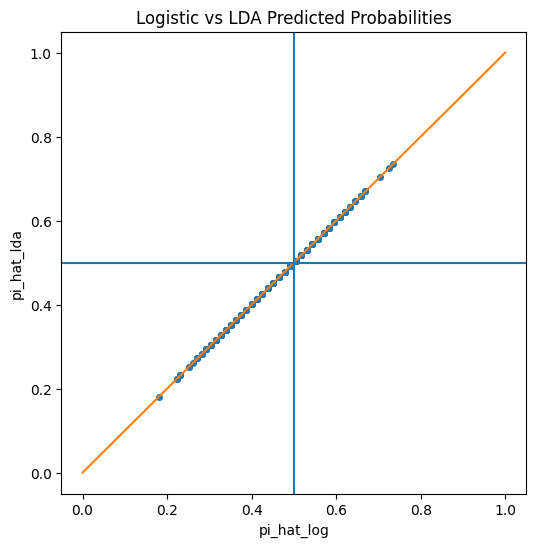

In [15]:
# --------------------
# Part 2E
# --------------------

plt.figure(figsize=(6, 6))
plt.plot(pi_hat_log, pi_hat_lda, 'o', markersize=4)
plt.plot([0, 1], [0, 1])   # abline(0,1)

tau = 0.5
plt.axhline(y=tau)
plt.axvline(x=tau)

plt.xlabel("pi_hat_log")
plt.ylabel("pi_hat_lda")
plt.title("Logistic vs LDA Predicted Probabilities")
plt.show()

Decision boundary (age): 57.66533066132264


/Users/dkhun/venvs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


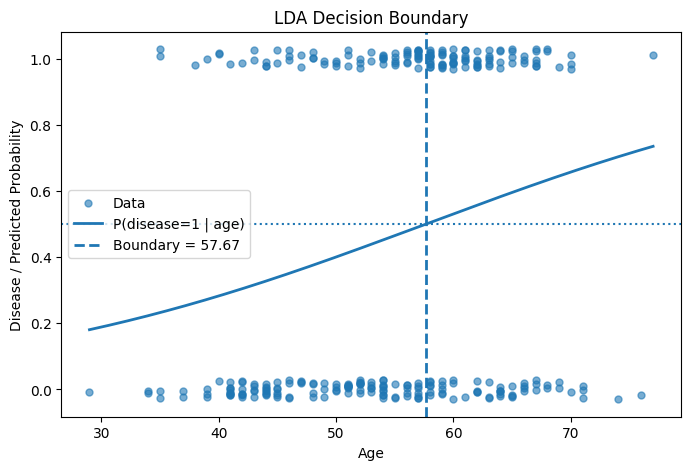

In [16]:
# predicted probabilities over a grid of age values
age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 500).reshape(-1, 1)
prob_1 = lda.predict_proba(age_grid)[:, 1]

# find decision boundary where P(y=1) crosses 0.5
boundary_idx = np.argmin(np.abs(prob_1 - 0.5))
decision_boundary = age_grid[boundary_idx, 0]

print("Decision boundary (age):", decision_boundary)

# plot
plt.figure(figsize=(8, 5))

# jitter y a little so points don't overlap too much
y_jitter = y + np.random.uniform(-0.03, 0.03, size=len(y))
plt.scatter(heart["age"], y_jitter, alpha=0.6, s=25, label="Data")

# probability curve
plt.plot(age_grid, prob_1, linewidth=2, label="P(disease=1 | age)")

# boundary line
plt.axvline(decision_boundary, linestyle="--", linewidth=2, label=f"Boundary = {decision_boundary:.2f}")
plt.axhline(0.5, linestyle=":")

plt.xlabel("Age")
plt.ylabel("Disease / Predicted Probability")
plt.title("LDA Decision Boundary")
plt.legend()
plt.show()

## Quadratic Discriminant Analysis

In [17]:
# --------------------
# Part 2F
# --------------------

# qda(disease ~ age, data=heart)
qda = QuadraticDiscriminantAnalysis()
X_qda = heart[["age"]]
y = heart["disease"]

qda.fit(X_qda, y)

# predict(qda)$posterior[,2]
pi_hat_qda = qda.predict_proba(X_qda)[:, 1]
print("First 5 QDA predicted probabilities:")
print(pi_hat_qda[:5])

tau = 0.5
yhat_qda = (pi_hat_qda >= tau).astype(int)
print("\nFirst 5 QDA predicted classes:")
print(yhat_qda[:5])

acc_qda = (yhat_qda == y).mean()
print("\nQDA Accuracy:", acc_qda)

# table(yhat_qda, y)
conf_matrix_qda = pd.crosstab(yhat_qda, y, rownames=["yhat_qda"], colnames=["y"])
print("\nQDA Confusion table:")
print(conf_matrix_qda)

First 5 QDA predicted probabilities:
[0.57699027 0.58029993 0.58029993 0.14777533 0.22933172]

First 5 QDA predicted classes:
[1 1 1 0 0]

QDA Accuracy: 0.6430976430976431

QDA Confusion table:
y          0   1
yhat_qda        
0         96  42
1         64  95


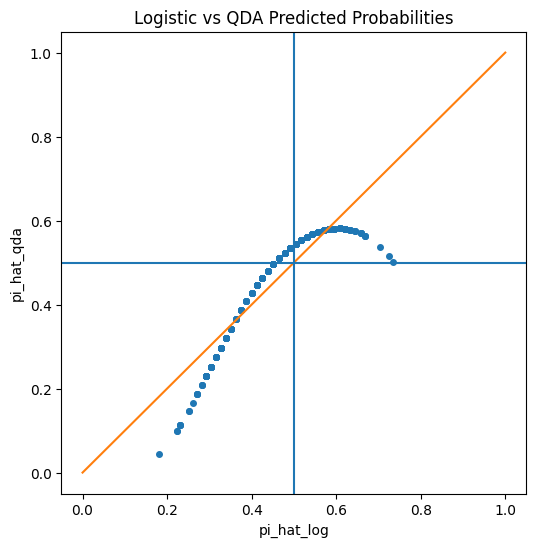

In [18]:
# --------------------
# Part 2G
# --------------------

plt.figure(figsize=(6, 6))
plt.plot(pi_hat_log, pi_hat_qda, 'o', markersize=4)
plt.plot([0, 1], [0, 1])   # abline(0,1)

tau = 0.5
plt.axhline(y=tau)
plt.axvline(x=tau)

plt.xlabel("pi_hat_log")
plt.ylabel("pi_hat_qda")
plt.title("Logistic vs QDA Predicted Probabilities")
plt.show()

## Multiple Regression Model

In [19]:
# --------------------
# Part 3A
# --------------------

mlr = smf.glm(
    formula="""
        disease ~ age + sex + cp + trestbps + chol + fbs + restecg
                + thalach + exang + oldpeak + slope + ca + thal
    """,
    data=heart,
    family=sm.families.Binomial()
).fit()

print(mlr.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  297
Model:                            GLM   Df Residuals:                      278
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -95.821
Date:                Tue, 17 Mar 2026   Deviance:                       191.64
Time:                        15:29:34   Pearson chi2:                     313.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5205
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [20]:
# --------------------
# Part 3B
# --------------------

pi_hat_mlr = mlr.predict(heart)
print("First 5 predicted probabilities:")
print(pi_hat_mlr.head())

tau = 0.5
yhat_mlr = (pi_hat_mlr >= tau).astype(int)
print("\nFirst 5 predicted classes:")
print(yhat_mlr.head())

y = heart["disease"]
acc_mlr = (yhat_mlr == y).mean()
print("\nAccuracy:", acc_mlr)

conf_matrix_mlr = pd.crosstab(yhat_mlr, y, rownames=["yhat_mlr"], colnames=["y"])
print("\nConfusion table:")
print(conf_matrix_mlr)

First 5 predicted probabilities:
0    0.097544
1    0.998827
2    0.996395
3    0.118801
4    0.033802
dtype: float64

First 5 predicted classes:
0    0
1    1
2    1
3    0
4    0
dtype: int64

Accuracy: 0.8720538720538721

Confusion table:
y           0    1
yhat_mlr          
0         146   24
1          14  113


In [21]:
def make_roc(y, ph, clr="red", new_plot=True, dt=0.001):
    taus = np.arange(0, 1 + dt, dt)

    sens = np.zeros(len(taus))
    fpr = np.zeros(len(taus))

    y = np.array(y)
    ph = np.array(ph)

    for i, tau in enumerate(taus):
        sens[i] = np.mean(ph[y == 1] > tau)
        fpr[i] = np.mean(ph[y == 0] > tau)

    if new_plot:
        plt.figure(figsize=(6, 6))
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("Sensitivity")
        plt.plot([0, 1], [0, 1])
        plt.axhline(0)
        plt.axhline(1)
        plt.axvline(0)
        plt.axvline(1)

    plt.plot(fpr, sens, color=clr, linewidth=2)

    auc = np.sum(((sens[1:] + sens[:-1]) / 2) * (fpr[:-1] - fpr[1:]))
    return auc

AUC: 0.9350593065693431


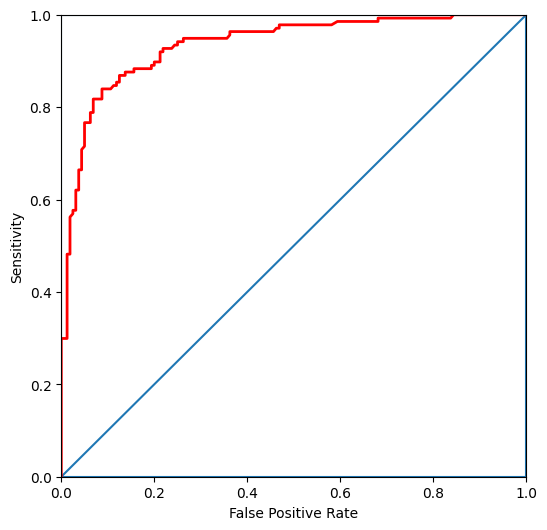

In [22]:
auc_mlr = make_roc(y, pi_hat_mlr)
print("AUC:", auc_mlr)
plt.show()

In [23]:
# response
y = heart["disease"]

# predictors
predictors = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

# make design matrix with dummy variables for categorical columns
X_mult = pd.get_dummies(heart[predictors], drop_first=True)

Logistic AUC: 0.9350593065693431

First 5 LDA predicted probabilities:
[0.09318478 0.99754692 0.99722273 0.05077394 0.01383985]

First 5 LDA predicted classes:
[0 1 1 0 0]

LDA Accuracy: 0.8686868686868687

LDA Confusion table:
y           0    1
yhat_lda          
0         146   25
1          14  112

LDA AUC: 0.9312956204379562

First 5 QDA predicted probabilities:
[3.31035467e-02 9.99999652e-01 9.99987170e-01 1.77024216e-03
 1.11339356e-05]

First 5 QDA predicted classes:
[0 1 1 0 0]

QDA Accuracy: 0.8720538720538721

QDA Confusion table:
y           0    1
yhat_qda          
0         147   25
1          13  112

QDA AUC: 0.9322080291970802


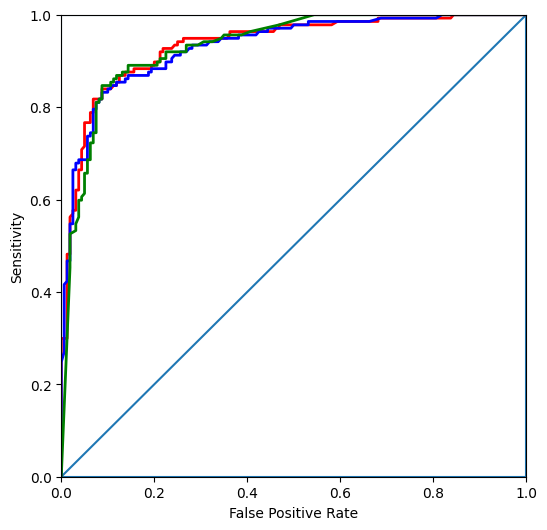

In [24]:
# --------------------
# Part 3C
# --------------------

# ROC for logistic model
auc_mlr = make_roc(y, pi_hat_mlr, "red", new_plot=True)
print("Logistic AUC:", auc_mlr)

# LDA model
lda_mult = LinearDiscriminantAnalysis()
lda_mult.fit(X_mult, y)

pi_hat_lda = lda_mult.predict_proba(X_mult)[:, 1]
print("\nFirst 5 LDA predicted probabilities:")
print(pi_hat_lda[:5])

tau = 0.5
yhat_lda = (pi_hat_lda >= tau).astype(int)
print("\nFirst 5 LDA predicted classes:")
print(yhat_lda[:5])

acc_lda = (yhat_lda == y).mean()
print("\nLDA Accuracy:", acc_lda)

conf_matrix_lda = pd.crosstab(yhat_lda, y, rownames=["yhat_lda"], colnames=["y"])
print("\nLDA Confusion table:")
print(conf_matrix_lda)

auc_lda = make_roc(y, pi_hat_lda, "blue", new_plot=False)
print("\nLDA AUC:", auc_lda)

# QDA model
qda_mult = QuadraticDiscriminantAnalysis()
qda_mult.fit(X_mult, y)

pi_hat_qda = qda_mult.predict_proba(X_mult)[:, 1]
print("\nFirst 5 QDA predicted probabilities:")
print(pi_hat_qda[:5])

yhat_qda = (pi_hat_qda >= tau).astype(int)
print("\nFirst 5 QDA predicted classes:")
print(yhat_qda[:5])

acc_qda = (yhat_qda == y).mean()
print("\nQDA Accuracy:", acc_qda)

conf_matrix_qda = pd.crosstab(yhat_qda, y, rownames=["yhat_qda"], colnames=["y"])
print("\nQDA Confusion table:")
print(conf_matrix_qda)

auc_qda = make_roc(y, pi_hat_qda, "green", new_plot=False)
print("\nQDA AUC:", auc_qda)

plt.show()

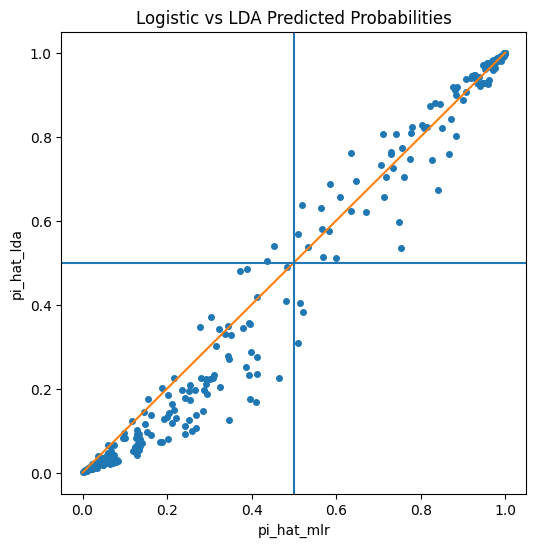

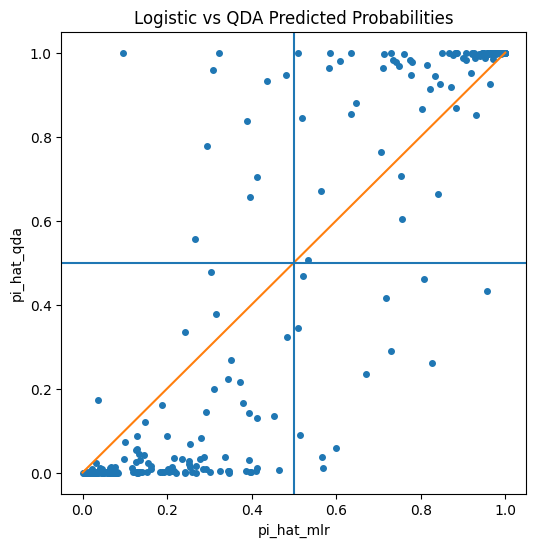

In [25]:
# --------------------
# Part 3D
# --------------------

tau = 0.5

# logistic vs LDA
plt.figure(figsize=(6, 6))
plt.plot(pi_hat_mlr, pi_hat_lda, 'o', markersize=4)
plt.plot([0, 1], [0, 1])
plt.axhline(y=tau)
plt.axvline(x=tau)
plt.xlabel("pi_hat_mlr")
plt.ylabel("pi_hat_lda")
plt.title("Logistic vs LDA Predicted Probabilities")
plt.show()

# logistic vs QDA
plt.figure(figsize=(6, 6))
plt.plot(pi_hat_mlr, pi_hat_qda, 'o', markersize=4)
plt.plot([0, 1], [0, 1])
plt.axhline(y=tau)
plt.axvline(x=tau)
plt.xlabel("pi_hat_mlr")
plt.ylabel("pi_hat_qda")
plt.title("Logistic vs QDA Predicted Probabilities")
plt.show()

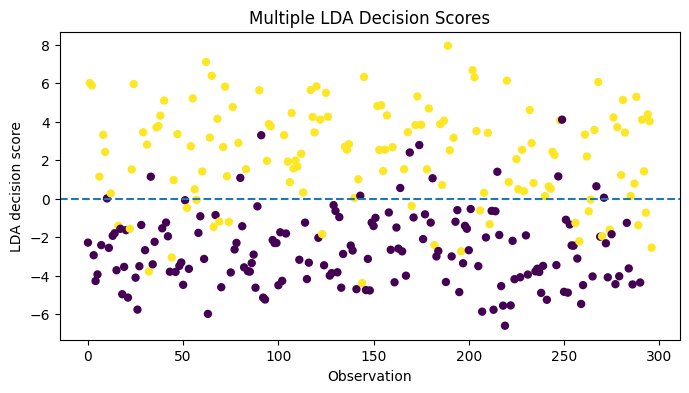

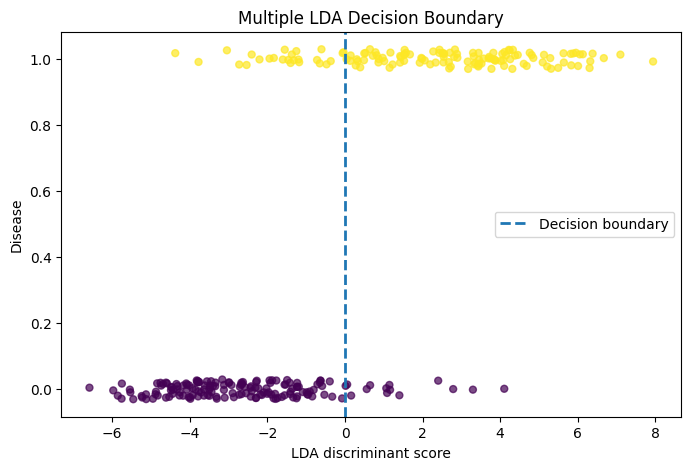

In [26]:
scores = lda_mult.decision_function(X_mult)

plt.figure(figsize=(8, 4))
plt.scatter(range(len(scores)), scores, c=y, s=25)
plt.axhline(0, linestyle="--")
plt.xlabel("Observation")
plt.ylabel("LDA decision score")
plt.title("Multiple LDA Decision Scores")
plt.show()

scores = lda_mult.decision_function(X_mult)

# small jitter for visibility
y_jitter = y + np.random.uniform(-0.03, 0.03, size=len(y))

plt.figure(figsize=(8, 5))
plt.scatter(scores, y_jitter, c=y, s=25, alpha=0.7)
plt.axvline(0, linestyle="--", linewidth=2, label="Decision boundary")
plt.xlabel("LDA discriminant score")
plt.ylabel("Disease")
plt.title("Multiple LDA Decision Boundary")
plt.legend()
plt.show()